# Credit Risk Analysis using Machine Learning

## Business Problem

Financial institutions face significant losses when customers fail to repay their credit card bills. Accurately identifying customers who are likely to default enables banks to reduce credit risk, improve lending decisions, and optimize portfolio performance.

The objective of this project is to develop a machine learning model that predicts whether a customer will default on their next credit card payment using demographic information, historical billing records, repayment history, and engineered financial features.

## Project Workflow

- SQL Data Validation
- SQL Feature Engineering
- SQL Business Analysis
- Exploratory Data Analysis (Python)
- Data Preprocessing
- Machine Learning Model Development
- Model Evaluation
- Business Recommendations

In [70]:
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot Style
plt.style.use("ggplot")

%pip install xgboost

%pip install -U optuna

%pip install -U shap

print("Libraries imported successfully.")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.


In [71]:
df = pd.read_csv("credit_card_features.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [72]:
df.sample(5)

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month,average_bill,average_payment,credit_utilization_ratio,payment_to_bill_ratio,average_delay,maximum_delay,delay_frequency,bill_volatility,payment_volatility,credit_limit_band,age_band,utilization_band,payment_ratio_band,delay_category
15681,16460,80000,2,2,1,57,2,2,-2,-2,-2,-2,82150,0,0,0,0,0,0,0,0,0,0,0,1,13691.67,0.00,0.1711,0.0000,-0.67,2,2,33537.60,0.00,Low,50-59,Low,Low,Occasionally Late
15018,15175,30000,2,2,2,23,0,0,0,0,0,0,34084,33476,32006,31672,31247,30673,1521,1573,1500,1300,1300,1329,0,32193.00,1420.50,1.0731,0.0441,0.00,0,0,1321.64,124.17,Very Low,21-29,Very High,Low,Never Late
12339,12179,260000,2,1,1,35,0,0,0,0,0,0,89420,86716,82868,80715,76377,44627,3578,2400,2000,2000,1464,1188,0,76787.17,2105.00,0.2953,0.0274,0.00,0,0,16401.34,840.31,High,30-39,Low,Low,Never Late
23464,72,320000,1,2,2,29,2,2,2,2,2,2,58267,59246,60184,58622,62307,63526,2500,2500,0,4800,2400,1600,1,60358.67,2300.00,0.1886,0.0381,2.00,2,6,2120.74,1556.92,High,21-29,Low,Low,Chronically Late
29372,29341,20000,1,4,2,27,-1,-1,-1,-1,-1,-1,543,2070,370,-20,780,0,1100,5193,0,800,0,0,0,623.83,1182.17,0.0312,1.8950,-1.00,-1,0,773.36,2021.49,Very Low,21-29,Low,Very High,Never Late


In [73]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (30000, 39)


In [74]:
df.columns.tolist()

['id',
 'limit_bal',
 'sex',
 'education',
 'marriage',
 'age',
 'pay_0',
 'pay_2',
 'pay_3',
 'pay_4',
 'pay_5',
 'pay_6',
 'bill_amt1',
 'bill_amt2',
 'bill_amt3',
 'bill_amt4',
 'bill_amt5',
 'bill_amt6',
 'pay_amt1',
 'pay_amt2',
 'pay_amt3',
 'pay_amt4',
 'pay_amt5',
 'pay_amt6',
 'default_payment_next_month',
 'average_bill',
 'average_payment',
 'credit_utilization_ratio',
 'payment_to_bill_ratio',
 'average_delay',
 'maximum_delay',
 'delay_frequency',
 'bill_volatility',
 'payment_volatility',
 'credit_limit_band',
 'age_band',
 'utilization_band',
 'payment_ratio_band',
 'delay_category']

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          30000 non-null  int64  
 1   limit_bal                   30000 non-null  int64  
 2   sex                         30000 non-null  int64  
 3   education                   30000 non-null  int64  
 4   marriage                    30000 non-null  int64  
 5   age                         30000 non-null  int64  
 6   pay_0                       30000 non-null  int64  
 7   pay_2                       30000 non-null  int64  
 8   pay_3                       30000 non-null  int64  
 9   pay_4                       30000 non-null  int64  
 10  pay_5                       30000 non-null  int64  
 11  pay_6                       30000 non-null  int64  
 12  bill_amt1                   30000 non-null  int64  
 13  bill_amt2                   300

In [76]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,30000.0,15000.500000,8660.398374,1.0000,7500.750000,15000.5000,22500.250000,3.000000e+04
limit_bal,30000.0,167484.322667,129747.661567,10000.0000,50000.000000,140000.0000,240000.000000,1.000000e+06
sex,30000.0,1.603733,0.489129,1.0000,1.000000,2.0000,2.000000,2.000000e+00
education,30000.0,1.842267,0.744494,1.0000,1.000000,2.0000,2.000000,4.000000e+00
marriage,30000.0,1.557267,0.521405,1.0000,1.000000,2.0000,2.000000,3.000000e+00
age,30000.0,35.485500,9.217904,21.0000,28.000000,34.0000,41.000000,7.900000e+01
pay_0,30000.0,-0.016700,1.123802,-2.0000,-1.000000,0.0000,0.000000,8.000000e+00
pay_2,30000.0,-0.133767,1.197186,-2.0000,-1.000000,0.0000,0.000000,8.000000e+00
pay_3,30000.0,-0.166200,1.196868,-2.0000,-1.000000,0.0000,0.000000,8.000000e+00
pay_4,30000.0,-0.220667,1.169139,-2.0000,-1.000000,0.0000,0.000000,8.000000e+00


## Exploratory Data Analysis (EDA)

The purpose of EDA is to understand the characteristics of the dataset, identify patterns associated with credit default, and explore relationships between variables before model development.

In [77]:
# =====================================================
# Target Variable Distribution
# =====================================================

target_counts = df["default_payment_next_month"].value_counts()

print(target_counts)

print("\n")

print(df["default_payment_next_month"].value_counts(normalize=True) * 100)

default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64


default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64


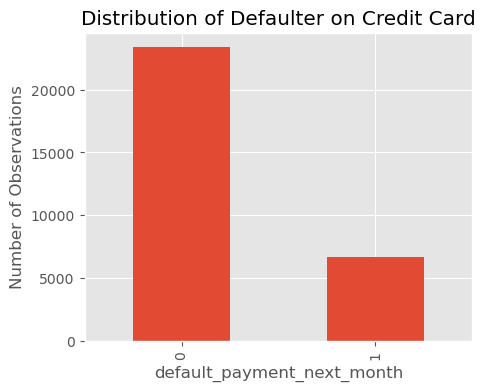

In [78]:
import matplotlib.pyplot as plt

df["default_payment_next_month"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Distribution of Defaulter on Credit Card")
plt.xlabel("default_payment_next_month")
plt.ylabel("Number of Observations")
plt.show()

### Statistical Exploratory Data Analysis

Unlike the SQL phase, which focused on business insights and portfolio analysis, this section examines the statistical properties of the features that will be used for predictive modeling. The objectives are to:

- Understand feature distributions
- Identify skewness and extreme values
- Detect potential outliers
- Assess suitability for machine learning algorithms

In [79]:
# =====================================================
# Continuous Features Used for Modeling
# =====================================================

continuous_features = [
    "limit_bal",
    "age",
    "average_bill",
    "average_payment",
    "credit_utilization_ratio",
    "payment_to_bill_ratio",
    "average_delay",
    "bill_volatility",
    "payment_volatility"
]

In [80]:
# =====================================================
# Summary Statistics
# =====================================================

summary = pd.DataFrame({
    "Mean": df[continuous_features].mean(),
    "Median": df[continuous_features].median(),
    "Std Dev": df[continuous_features].std(),
    "Min": df[continuous_features].min(),
    "Max": df[continuous_features].max(),
    "Skewness": df[continuous_features].skew(),
    "Kurtosis": df[continuous_features].kurtosis()
})

summary.round(3)

,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
limit_bal,167484.323,140000.000,129747.662,10000.000,1000000.000,0.993,0.536
age,35.486,34.000,9.218,21.000,79.000,0.732,0.044
average_bill,44976.945,21051.835,63260.722,-56043.170,877313.830,2.735,10.524
average_payment,5275.232,2397.165,10137.946,0.000,627344.330,14.617,607.756
credit_utilization_ratio,0.373,0.285,0.352,-0.233,5.364,0.666,0.884
payment_to_bill_ratio,0.381,0.085,7.675,-547.712,797.080,13.166,6045.025
average_delay,-0.183,0.000,0.982,-2.000,6.000,0.693,2.695
bill_volatility,12077.788,4579.660,20302.149,0.000,647788.050,4.864,54.996
payment_volatility,5804.919,1413.695,15006.439,0.000,650098.340,9.986,233.298


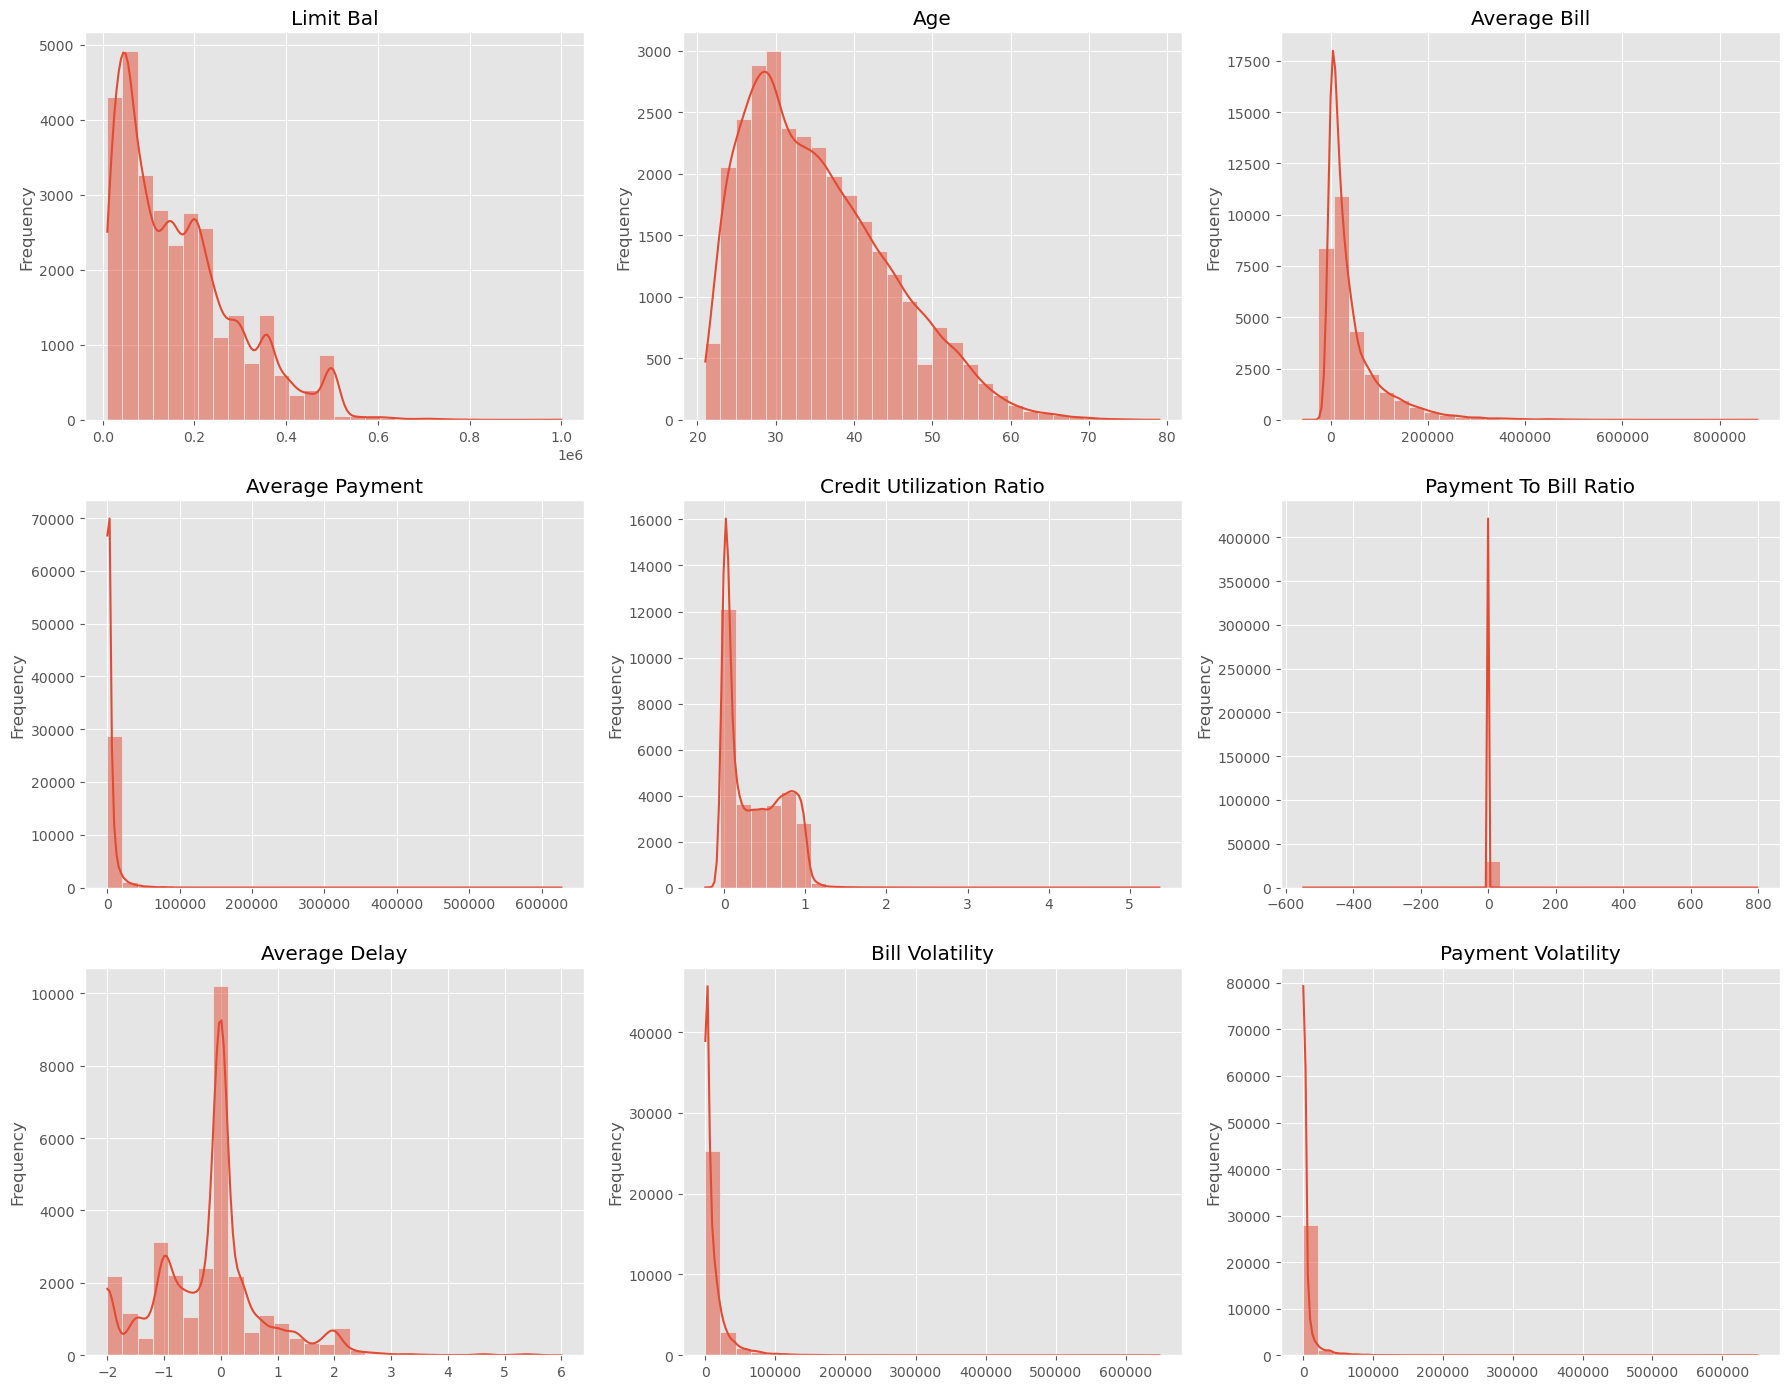

In [81]:
# =====================================================
# Distribution of Continuous Features
# =====================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

axes = axes.flatten()

for i, col in enumerate(continuous_features):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        ax=axes[i]
    )

    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()

plt.show()

### Interpretation

The summary statistics reveal substantial variation in the distributions of the continuous variables.

- **Credit Limit (`limit_bal`)** and **Age (`age`)** exhibit moderate positive skewness, indicating that most customers have relatively lower credit limits and are concentrated in younger age groups, with a smaller number of customers at the upper end of the distribution.

- The engineered financial variables **Average Bill**, **Average Payment**, **Bill Volatility**, and **Payment Volatility** are highly right-skewed with large kurtosis values. This indicates the presence of a small number of customers with exceptionally large transaction amounts or highly variable spending behaviour.

- **Payment-to-Bill Ratio** exhibits the highest dispersion and extreme kurtosis, suggesting the existence of substantial outliers. This behaviour is expected because customers may occasionally make payments that greatly exceed or fall below their outstanding bills.

- **Credit Utilization Ratio** shows only mild skewness and appears relatively well-behaved compared to the other financial variables, although some customers have utilization levels exceeding one, indicating balances greater than their assigned credit limit.

- **Average Delay** is centred close to zero with comparatively low variability, suggesting that most customers make payments on time or with only minor delays.

Overall, the distributions indicate that several financial variables are non-normal and contain extreme values, which will be examined further through outlier analysis before deciding whether any transformations or robust preprocessing techniques are required.

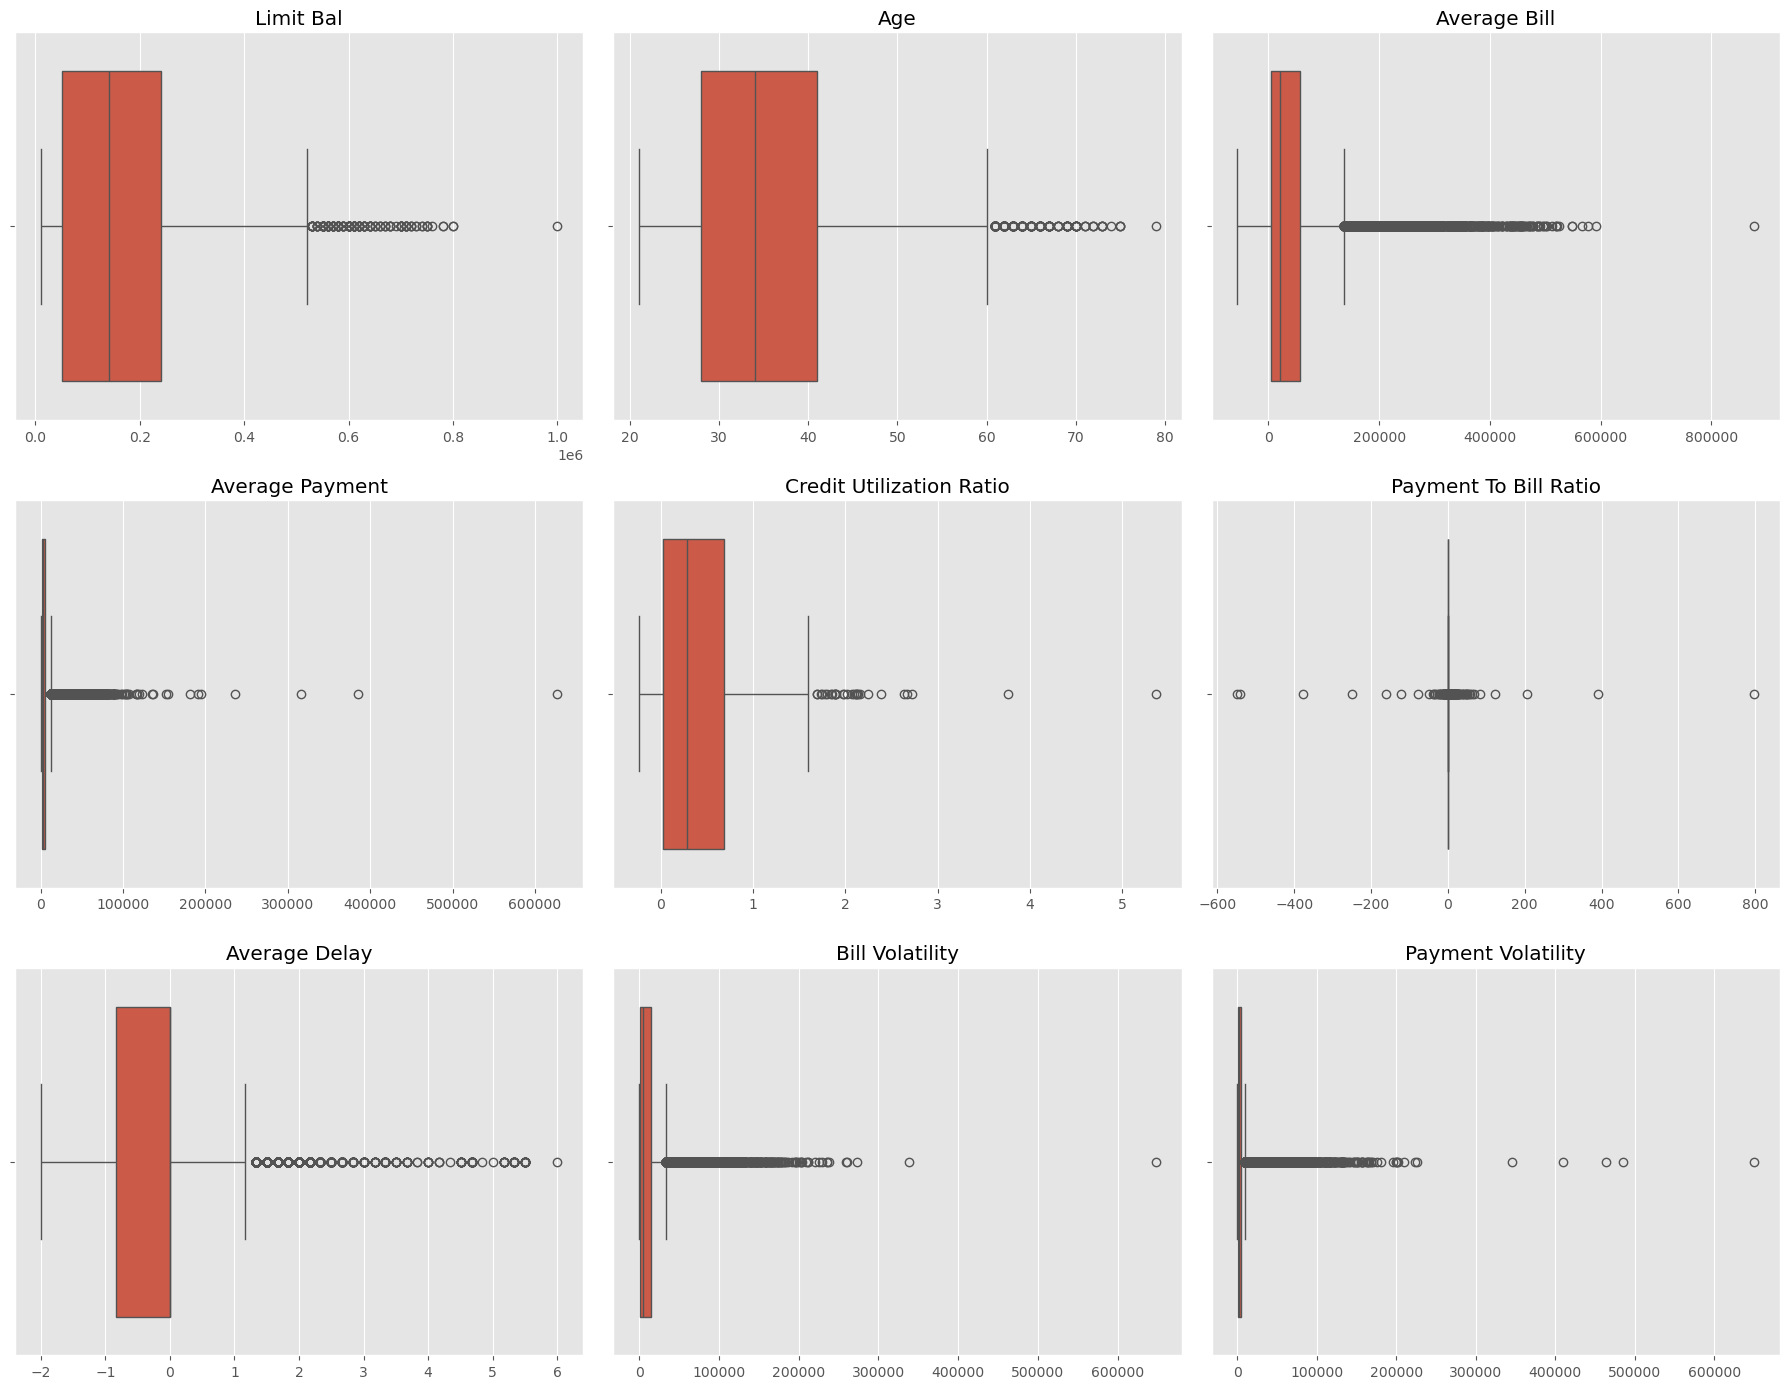

In [82]:
# =====================================================
# Boxplots of Continuous Features
# =====================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

axes = axes.flatten()

for i, col in enumerate(continuous_features):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("")

plt.tight_layout()

plt.show()

## Feature Selection

In [83]:
corr_features = [
    "limit_bal",
    "age",
    "average_bill",
    "average_payment",
    "credit_utilization_ratio",
    "payment_to_bill_ratio",
    "average_delay",
    "bill_volatility",
    "payment_volatility"
]

corr_matrix = df[corr_features].corr().round(2)

corr_matrix

,limit_bal,age,average_bill,average_payment,credit_utilization_ratio,payment_to_bill_ratio,average_delay,bill_volatility,payment_volatility
limit_bal,1.00,0.14,0.30,0.35,-0.38,0.03,-0.32,0.29,0.27
age,0.14,1.00,0.05,0.04,-0.04,0.00,-0.06,0.04,0.02
average_bill,0.30,0.05,1.00,0.34,0.55,-0.02,0.28,0.48,0.21
average_payment,0.35,0.04,0.34,1.00,0.03,0.02,-0.07,0.56,0.89
credit_utilization_ratio,-0.38,-0.04,0.55,0.03,1.00,-0.04,0.56,0.16,-0.02
payment_to_bill_ratio,0.03,0.00,-0.02,0.02,-0.04,1.00,-0.04,-0.01,0.03
average_delay,-0.32,-0.06,0.28,-0.07,0.56,-0.04,1.00,0.00,-0.08
bill_volatility,0.29,0.04,0.48,0.56,0.16,-0.01,0.00,1.00,0.59
payment_volatility,0.27,0.02,0.21,0.89,-0.02,0.03,-0.08,0.59,1.00


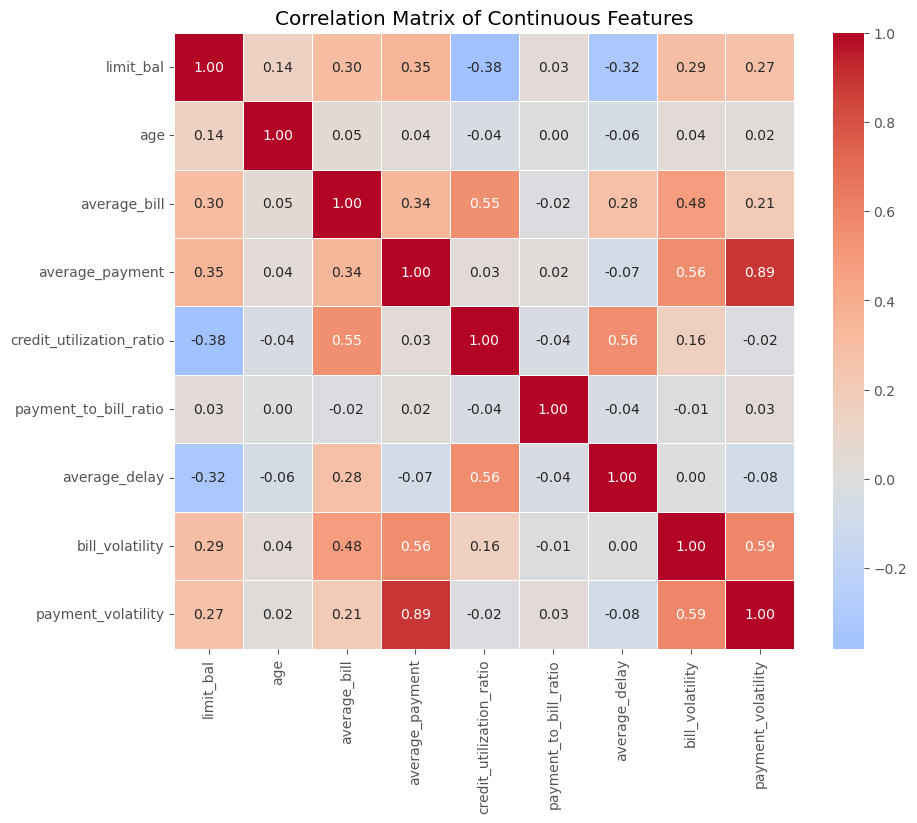

In [84]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Continuous Features")

plt.show()

In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =====================================================
# Variance Inflation Factor (VIF)
# =====================================================

X_vif = df[continuous_features].copy()

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif.round(2)

,Feature,VIF
3,average_payment,7.48
8,payment_volatility,6.94
1,age,5.99
0,limit_bal,5.08
4,credit_utilization_ratio,4.95
2,average_bill,4.19
7,bill_volatility,2.65
6,average_delay,1.55
5,payment_to_bill_ratio,1.01


In [86]:
bill_features = [
    "bill_amt1", "bill_amt2", "bill_amt3",
    "bill_amt4", "bill_amt5", "bill_amt6",
    "average_bill",
    "bill_volatility"
]

bill_corr = df[bill_features].corr().round(2)

bill_corr

,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,average_bill,bill_volatility
bill_amt1,1.00,0.95,0.89,0.86,0.83,0.80,0.94,0.56
bill_amt2,0.95,1.00,0.93,0.89,0.86,0.83,0.96,0.52
bill_amt3,0.89,0.93,1.00,0.92,0.88,0.85,0.96,0.51
bill_amt4,0.86,0.89,0.92,1.00,0.94,0.90,0.96,0.41
bill_amt5,0.83,0.86,0.88,0.94,1.00,0.95,0.95,0.35
bill_amt6,0.80,0.83,0.85,0.90,0.95,1.00,0.93,0.32
average_bill,0.94,0.96,0.96,0.96,0.95,0.93,1.00,0.48
bill_volatility,0.56,0.52,0.51,0.41,0.35,0.32,0.48,1.00


In [87]:
payment_features = [
    "pay_amt1", "pay_amt2", "pay_amt3",
    "pay_amt4", "pay_amt5", "pay_amt6",
    "average_payment",
    "payment_volatility"
]

payment_corr = df[payment_features].corr().round(2)

payment_corr

,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,average_payment,payment_volatility
pay_amt1,1.00,0.29,0.25,0.20,0.15,0.19,0.60,0.49
pay_amt2,0.29,1.00,0.24,0.18,0.18,0.16,0.67,0.62
pay_amt3,0.25,0.24,1.00,0.22,0.16,0.16,0.59,0.51
pay_amt4,0.20,0.18,0.22,1.00,0.15,0.16,0.53,0.46
pay_amt5,0.15,0.18,0.16,0.15,1.00,0.15,0.49,0.46
pay_amt6,0.19,0.16,0.16,0.16,0.15,1.00,0.53,0.50
average_payment,0.60,0.67,0.59,0.53,0.49,0.53,1.00,0.89
payment_volatility,0.49,0.62,0.51,0.46,0.46,0.50,0.89,1.00


In [88]:
delay_features = [
    "pay_0", "pay_2", "pay_3",
    "pay_4", "pay_5", "pay_6",
    "average_delay",
    "maximum_delay",
    "delay_frequency"
]

delay_corr = df[delay_features].corr().round(2)

delay_corr

,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,average_delay,maximum_delay,delay_frequency
pay_0,1.00,0.67,0.57,0.54,0.51,0.47,0.74,0.77,0.64
pay_2,0.67,1.00,0.77,0.66,0.62,0.58,0.85,0.69,0.66
pay_3,0.57,0.77,1.00,0.78,0.69,0.63,0.88,0.70,0.65
pay_4,0.54,0.66,0.78,1.00,0.82,0.72,0.89,0.67,0.63
pay_5,0.51,0.62,0.69,0.82,1.00,0.82,0.88,0.64,0.61
pay_6,0.47,0.58,0.63,0.72,0.82,1.00,0.83,0.63,0.56
average_delay,0.74,0.85,0.88,0.89,0.88,0.83,1.00,0.81,0.74
maximum_delay,0.77,0.69,0.70,0.67,0.64,0.63,0.81,1.00,0.76
delay_frequency,0.64,0.66,0.65,0.63,0.61,0.56,0.74,0.76,1.00


In [89]:
# VIF

all_features = [

    # Customer Information
    "limit_bal",
    "age",

    # Repayment Status
    "pay_0",
    "pay_2",
    "pay_3",
    "pay_4",
    "pay_5",
    "pay_6",

    # Monthly Bills
    "bill_amt1",
    "bill_amt2",
    "bill_amt3",
    "bill_amt4",
    "bill_amt5",
    "bill_amt6",

    # Monthly Payments
    "pay_amt1",
    "pay_amt2",
    "pay_amt3",
    "pay_amt4",
    "pay_amt5",
    "pay_amt6",

    # Engineered Features
    "average_bill",
    "average_payment",
    "credit_utilization_ratio",
    "payment_to_bill_ratio",
    "average_delay",
    "maximum_delay",
    "delay_frequency",
    "bill_volatility",
    "payment_volatility"
]

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = df[all_features].copy()

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

,Feature,VIF
20,average_bill,9.007199e+14
8,bill_amt1,3.194042e+13
9,bill_amt2,2.972673e+13
10,bill_amt3,2.780000e+13
11,bill_amt4,2.382857e+13
12,bill_amt5,2.109414e+13
13,bill_amt6,2.006058e+13
21,average_payment,1.888302e+13
15,pay_amt2,2.272823e+12
19,pay_amt6,1.378301e+12


In [90]:
selected_features = [

    # Customer Information
    "limit_bal",
    "sex",
    "education",
    "marriage",
    "age",

    # Repayment History
    "pay_0",
    "pay_2",
    "pay_3",
    "pay_4",
    "pay_5",
    "pay_6",

    # Engineered Features
    "average_bill",
    "average_payment",
    "credit_utilization_ratio",
    "payment_to_bill_ratio",
    "bill_volatility",
    "payment_volatility"
]

## Final Feature Selection

Feature selection was performed using a combination of business understanding and statistical analysis rather than relying on a single automated method.

Initially, correlation analysis was conducted to identify highly correlated variables. This was followed by Variance Inflation Factor (VIF) analysis to detect multicollinearity among both the original and engineered variables.

The analysis revealed that several engineered variables were mathematical transformations of existing variables. For example, `average_bill` is derived directly from the six monthly bill amounts, while `average_payment` is calculated from the six monthly payment amounts. Including both the original variables and their engineered counterparts resulted in extremely high VIF values, indicating severe multicollinearity.

To reduce redundancy while preserving predictive information, a hybrid feature set was selected.

The final feature set consists of:

**Customer Information**
- LIMIT_BAL
- SEX
- EDUCATION
- MARRIAGE
- AGE

These variables describe the demographic and financial characteristics of the customer.

**Repayment History**
- PAY_0
- PAY_2
- PAY_3
- PAY_4
- PAY_5
- PAY_6

Monthly repayment status was retained because it preserves the temporal repayment pattern that cannot be fully represented by summary statistics such as average delay.

**Engineered Financial Features**
- average_bill
- average_payment
- credit_utilization_ratio
- payment_to_bill_ratio
- bill_volatility
- payment_volatility

These engineered variables summarize customer spending and payment behaviour while eliminating redundancy associated with six months of highly correlated billing and payment variables.

Variables such as the monthly bill amounts, monthly payment amounts, average delay, delay frequency, maximum delay, and categorical band variables were excluded because they either introduced severe multicollinearity or represented duplicate information already captured by retained variables.

In [91]:
from sklearn.model_selection import train_test_split

X = df[selected_features]
y = df["default_payment_next_month"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape) 

Training Set : (24000, 17)
Testing Set  : (6000, 17)


In [92]:
continuous_features = [
    "limit_bal",
    "age",
    "average_bill",
    "average_payment",
    "credit_utilization_ratio",
    "payment_to_bill_ratio",
    "bill_volatility",
    "payment_volatility"
]

summary = pd.DataFrame({
    "Skewness": df[continuous_features].skew(),
    "Kurtosis": df[continuous_features].kurtosis(),
    "Min": df[continuous_features].min(),
    "Q1": df[continuous_features].quantile(0.25),
    "Median": df[continuous_features].median(),
    "Q3": df[continuous_features].quantile(0.75),
    "99th Percentile": df[continuous_features].quantile(0.99),
    "Max": df[continuous_features].max()
})

summary

,Skewness,Kurtosis,Min,Q1,Median,Q3,99th Percentile,Max
limit_bal,0.992867,0.536263,10000.0000,50000.000000,140000.0000,240000.000000,500000.000000,1000000.0000
age,0.732246,0.044303,21.0000,28.000000,34.0000,41.000000,60.000000,79.0000
average_bill,2.734744,10.524208,-56043.1700,4781.332500,21051.8350,57104.420000,300288.190000,877313.8300
average_payment,14.616877,607.756073,0.0000,1113.290000,2397.1650,5583.915000,45100.656700,627344.3300
credit_utilization_ratio,0.665963,0.884482,-0.2326,0.030000,0.2848,0.687925,1.048405,5.3643
payment_to_bill_ratio,13.165657,6045.025304,-547.7124,0.040975,0.0849,0.586900,2.732907,797.0798
bill_volatility,4.864108,54.996345,0.0000,1549.935000,4579.6600,14352.260000,100821.612300,647788.0500
payment_volatility,9.985853,233.297541,0.0000,615.355000,1413.6950,4126.955000,70823.716500,650098.3400


## Outlier Treatment (Winsorization)

Outlier analysis was performed using boxplots together with distributional statistics, including skewness, kurtosis, and percentile summaries. The objective was to distinguish between genuine business observations and extreme values arising from derived variables.

Financial variables such as **Credit Limit**, **Average Bill Amount**, and **Average Payment Amount** naturally exhibit right-skewed distributions because customers differ substantially in their spending capacity and repayment behavior. These large values represent legitimate customer characteristics rather than data errors and were therefore retained.

In contrast, certain engineered variables displayed extremely long-tailed distributions due to their mathematical construction. The **Payment-to-Bill Ratio** can become disproportionately large when the average bill amount is close to zero, while **Bill Volatility** and **Payment Volatility** are standard deviation-based measures that are highly sensitive to extreme monthly observations.

Based on this analysis, selective winsorization was applied only to the following variables:

- `payment_to_bill_ratio`
- `bill_volatility`
- `payment_volatility`

All remaining variables were left unchanged to preserve genuine financial information.

To prevent data leakage, winsorization thresholds were estimated using only the training dataset and subsequently applied to both the training and testing datasets.

In [93]:
winsor_cols = [
    "payment_to_bill_ratio",
    "bill_volatility",
    "payment_volatility"
]

winsor_limits = {}

for col in winsor_cols:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)

    winsor_limits[col] = (lower, upper)

    X_train[col] = X_train[col].clip(lower=lower, upper=upper) 

In [94]:
for col in winsor_cols:
    lower, upper = winsor_limits[col]

    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

In [95]:
for col in winsor_cols:
    print(f"\n{col}")
    print("Train Min:", X_train[col].min())
    print("Train Max:", X_train[col].max())


payment_to_bill_ratio
Train Min: 0.0
Train Max: 2.6316

bill_volatility
Train Min: 0.0
Train Max: 98870.14629999909

payment_volatility
Train Min: 0.0
Train Max: 69853.11159999977


### Standardization

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

The training and testing datasets were standardized using the StandardScaler. The scaler was fitted only on the training data and subsequently applied to the testing data to prevent information leakage. Scaling was performed after winsorization so that the model was trained on the finalized feature distributions.

> ### Lasso Validation

In [97]:
from sklearn.linear_model import LogisticRegression

lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',      # or 'saga'
    C=1.0,
    random_state=42,
    max_iter=5000
)

lasso.fit(X_train, y_train)

LogisticRegression(max_iter=5000, penalty='l1', random_state=42,
                   solver='liblinear')

In [98]:
import pandas as pd

lasso_results = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso.coef_[0]
})

lasso_results["Absolute"] = lasso_results["Coefficient"].abs()

lasso_results["Selected"] = lasso_results["Coefficient"] != 0

lasso_results = (
    lasso_results
    .sort_values("Absolute", ascending=False)
    .reset_index(drop=True)
)

print(f"Total Features: {len(lasso_results)}")
print(f"Selected Features: {lasso_results['Selected'].sum()}")
print(f"Removed Features: {(~lasso_results['Selected']).sum()}")


lasso_results

Total Features: 17
Selected Features: 17
Removed Features: 0


,Feature,Coefficient,Absolute,Selected
0,average_payment,-0.996194,0.996194,True
1,pay_0,0.643983,0.643983,True
2,payment_volatility,0.563005,0.563005,True
3,average_bill,0.178427,0.178427,True
4,bill_volatility,-0.161674,0.161674,True
5,limit_bal,-0.135286,0.135286,True
6,payment_to_bill_ratio,0.120397,0.120397,True
7,pay_2,0.119269,0.119269,True
8,pay_3,0.103878,0.103878,True
9,marriage,-0.078431,0.078431,True


>Feature engineering introduced several summary variables derived from the original monthly billing and payment variables. To avoid redundant representations and multicollinearity, correlation analysis and Variance Inflation Factor (VIF) analysis were performed. Based on these diagnostics, redundant variables were removed while retaining predictors that provided complementary information. The resulting feature set was further validated using L1-regularized Logistic Regression (LASSO), which confirmed the predictive contribution of all retained variables.

We computed the capping thresholds using only the training data and then apply those same thresholds to both the training and test sets. That avoids introducing data leakage into the modeling process.

In [99]:
print(type(X_train))
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [100]:
summary = pd.DataFrame({
    "Mean": X_train.mean(),
    "Std": X_train.std()
})

print(summary.round(4))

                          Mean  Std
limit_bal                  0.0  1.0
sex                       -0.0  1.0
education                 -0.0  1.0
marriage                   0.0  1.0
age                        0.0  1.0
pay_0                      0.0  1.0
pay_2                     -0.0  1.0
pay_3                      0.0  1.0
pay_4                     -0.0  1.0
pay_5                      0.0  1.0
pay_6                     -0.0  1.0
average_bill               0.0  1.0
average_payment           -0.0  1.0
credit_utilization_ratio   0.0  1.0
payment_to_bill_ratio      0.0  1.0
bill_volatility            0.0  1.0
payment_volatility         0.0  1.0


### Class Imbalance Handling

In [101]:
y_train.value_counts()
y_train.value_counts(normalize=True) * 100

default_payment_next_month
0    77.879167
1    22.120833
Name: proportion, dtype: float64

The target variable exhibits a moderate class imbalance, with approximately 77.88% non-default cases and 22.12% default cases.

Rather than applying oversampling techniques such as SMOTE, class imbalance was addressed using algorithm-specific class weighting.

The following strategies were adopted:

- Logistic Regression: `class_weight='balanced'`
- Decision Tree: `class_weight='balanced'`
- Random Forest: `class_weight='balanced'`
- XGBoost: `scale_pos_weight`

In [102]:
# Compute XGBoost class weight from training data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(f"Negative samples: {neg}")
print(f"Positive samples: {pos}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

Negative samples: 18691
Positive samples: 5309
scale_pos_weight = 3.52


## Model Training 

In [103]:
# ============================================================
# Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ============================================================
# Containers
# ============================================================

results = []

trained_models = {}

model_probs = {}

confusion_matrices = {}

# ============================================================
# Evaluation Function
# ============================================================

def evaluate_model(model, model_name):

    print("="*80)
    print(model_name)
    print("="*80)

    # ------------------------
    # Train
    # ------------------------

    model.fit(X_train, y_train)

    trained_models[model_name] = model

    # ------------------------
    # Prediction
    # ------------------------

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    model_probs[model_name] = y_prob

    # ------------------------
    # Metrics
    # ------------------------

    accuracy = accuracy_score(y_test, y_pred)

    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    # ------------------------
    # Save Results
    # ------------------------

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Balanced Accuracy": balanced_accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc,

        "PR-AUC": pr_auc

    })

    # ------------------------
    # Print Results
    # ------------------------

    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Balanced Accuracy  : {balanced_accuracy:.4f}")
    print(f"Precision          : {precision:.4f}")
    print(f"Recall             : {recall:.4f}")
    print(f"F1 Score           : {f1:.4f}")
    print(f"ROC-AUC            : {roc_auc:.4f}")
    print(f"PR-AUC             : {pr_auc:.4f}")

    print("\nClassification Report\n")

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # ------------------------
    # Confusion Matrix
    # ------------------------

    cm = confusion_matrix(y_test, y_pred)

    confusion_matrices[model_name] = cm

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Default", "Default"],
        yticklabels=["Non-Default", "Default"]
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title(f"Confusion Matrix - {model_name}")

    plt.show()


    return model

`LogisticRegression`

Logistic Regression
Accuracy           : 0.7132
Balanced Accuracy  : 0.6769
Precision          : 0.4024
Recall             : 0.6119
F1 Score           : 0.4855
ROC-AUC            : 0.7226
PR-AUC             : 0.4919

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.74      0.80      4673
           1       0.40      0.61      0.49      1327

    accuracy                           0.71      6000
   macro avg       0.64      0.68      0.64      6000
weighted avg       0.77      0.71      0.73      6000



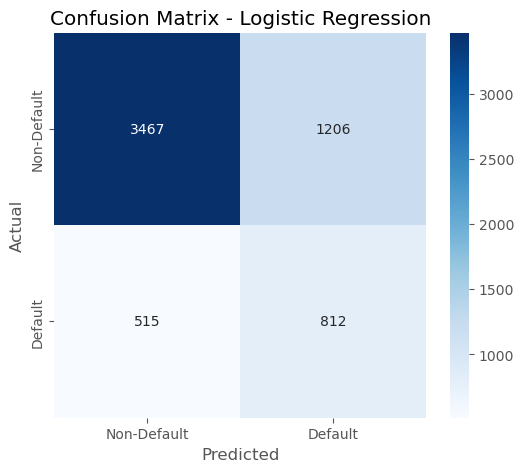

In [104]:
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=3000
)

lr = evaluate_model(
    lr,
    "Logistic Regression"
)

`Decision Tree`

Decision Tree
Accuracy           : 0.7297
Balanced Accuracy  : 0.6071
Precision          : 0.3885
Recall             : 0.3873
F1 Score           : 0.3879
ROC-AUC            : 0.6071
PR-AUC             : 0.2860

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      4673
           1       0.39      0.39      0.39      1327

    accuracy                           0.73      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.73      0.73      0.73      6000



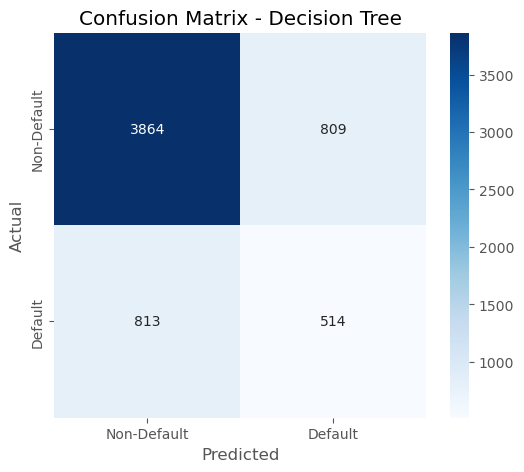

In [105]:
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt = evaluate_model(
    dt,
    "Decision Tree"
)

`Random Forest`

Random Forest
Accuracy           : 0.8107
Balanced Accuracy  : 0.6402
Precision          : 0.6370
Recall             : 0.3346
F1 Score           : 0.4387
ROC-AUC            : 0.7524
PR-AUC             : 0.5101

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.64      0.33      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000



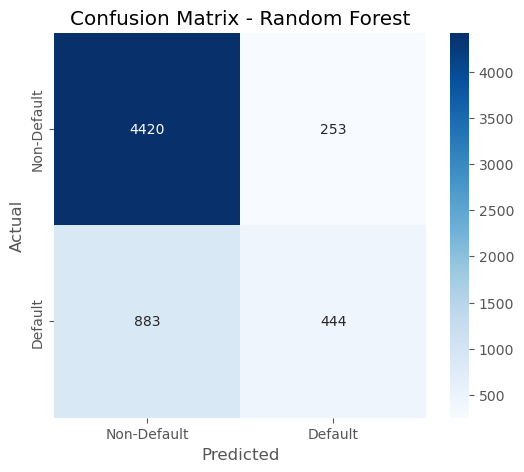

In [106]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf = evaluate_model(
    rf,
    "Random Forest"
)

`XGBoost`

XGBoost
Accuracy           : 0.7512
Balanced Accuracy  : 0.6843
Precision          : 0.4501
Recall             : 0.5644
F1 Score           : 0.5008
ROC-AUC            : 0.7459
PR-AUC             : 0.5133

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.80      0.83      4673
           1       0.45      0.56      0.50      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.68      0.67      6000
weighted avg       0.77      0.75      0.76      6000



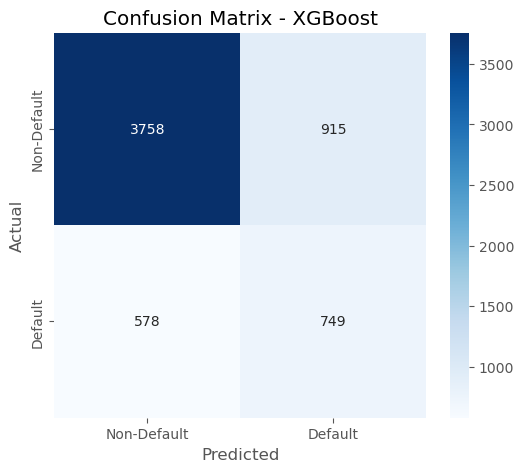

In [107]:
xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

xgb = evaluate_model(
    xgb,
    "XGBoost"
)

> Comaprison

In [108]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="PR-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.751167,0.684313,0.450120,0.564431,0.500836,0.745891,0.513290
1,Random Forest,0.810667,0.640224,0.637016,0.334589,0.438735,0.752395,0.510069
2,Logistic Regression,0.713167,0.676914,0.402379,0.611907,0.485501,0.722577,0.491925
3,Decision Tree,0.729667,0.607109,0.388511,0.387340,0.387925,0.607109,0.285986


### Baseline Model Comparison

The baseline results indicate that 

**XGBoost** achieved the highest **PR-AUC (0.513)** and **F1-score (0.501)**, suggesting the best balance between identifying default cases and minimizing false positives. Although 

**Random Forest** obtained the highest **Accuracy (81.07%)** and **ROC-AUC (0.752)**, its relatively low **Recall (33.46%)** indicates that many default cases were missed. 

**Logistic Regression** achieved the highest **Recall (61.19%)**, making it effective in detecting defaults, albeit with lower precision and overall performance.

**Decision Tree** showed the weakest predictive performance across most evaluation metrics. 

> ***ROC Curve***

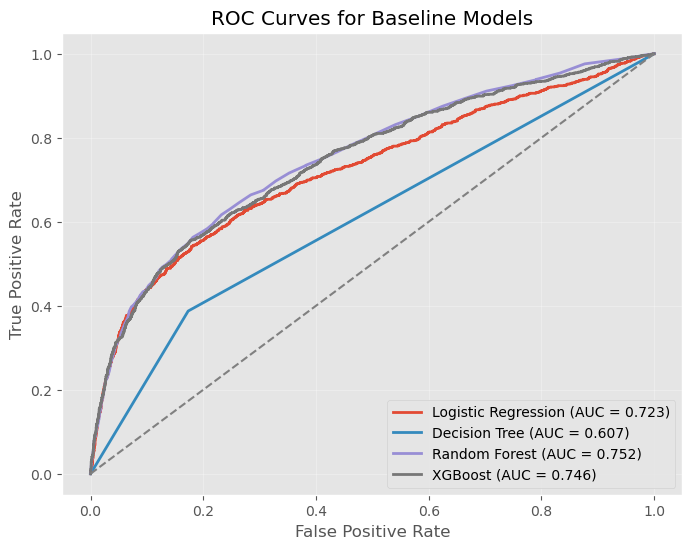

In [109]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for model_name, y_prob in model_probs.items():

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Baseline Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

> ***PR-AUC Curve***

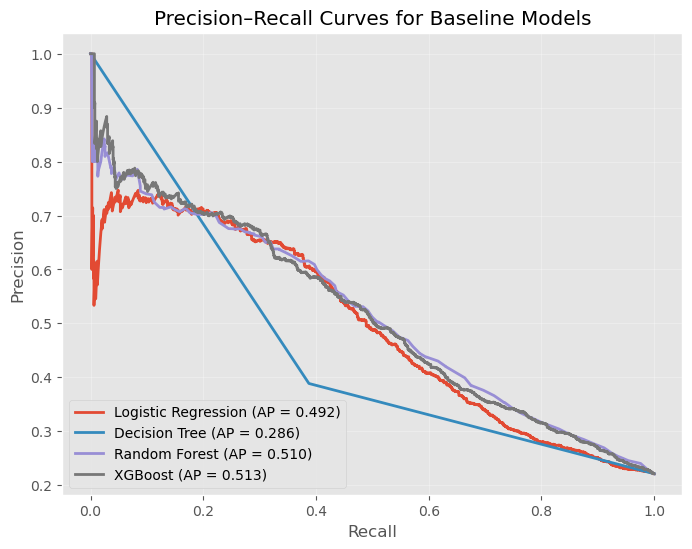

In [110]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

for model_name, y_prob in model_probs.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP = {pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for Baseline Models")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.show()

#### Model Selection for Hyperparameter Tuning

Based on the baseline evaluation metrics and the ROC and Precision–Recall curves,

**Decision Tree** was excluded from the hyperparameter tuning stage. It consistently exhibited the lowest predictive performance, recording the smallest ROC-AUC (0.607), PR-AUC (0.286), and F1-score (0.388), indicating inferior discriminative ability compared with the other models. 

In contrast, **XGBoost**, **Random Forest**, and **Logistic Regression** demonstrated stronger predictive performance and complementary strengths, making them more suitable candidates for further optimization. Consequently, hyperparameter tuning using Optuna was performed only for these three models to focus computational effort on the most promising algorithms.

### Hyperparameter Tuning

In [111]:
import optuna

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [112]:
# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Number of trials
N_TRIALS = 15

RANDOM_STATE = 42

In [113]:
def objective_lr(trial):

    solver = trial.suggest_categorical(
        "solver",
        ["liblinear", "lbfgs"]
    )

    if solver == "liblinear":
        penalty = trial.suggest_categorical(
            "penalty",
            ["l1", "l2"]
        )
    else:
        penalty = "l2"

    model = LogisticRegression(
        C=trial.suggest_float(
            "C",
            1e-3,
            100,
            log=True
        ),
        solver=solver,
        penalty=penalty,
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE
    )

    return cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    ).mean()

In [114]:
def objective_rf(trial):

    model = RandomForestClassifier(

        n_estimators=trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        max_depth=trial.suggest_int(
            "max_depth",
            3,
            30
        ),

        min_samples_split=trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        min_samples_leaf=trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        max_features=trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),

        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    return cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    ).mean()

In [115]:
def objective_xgb(trial):

    model = XGBClassifier(

        n_estimators=trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        learning_rate=trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        max_depth=trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        subsample=trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        colsample_bytree=trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        min_child_weight=trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        gamma=trial.suggest_float(
            "gamma",
            0,
            5
        ),

        reg_alpha=trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        reg_lambda=trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),

        scale_pos_weight=scale_pos_weight,

        eval_metric="logloss",

        random_state=RANDOM_STATE
    )

    return cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    ).mean()

In [116]:
def tune_model(objective_function, model_name):

    print("=" * 70)
    print(f"Tuning {model_name}")
    print("=" * 70)

    # Fix Optuna randomness
    sampler = optuna.samplers.TPESampler(seed=42)

    study = optuna.create_study(
        direction="maximize",
        study_name=model_name,
        sampler=sampler
    )

    study.optimize(
        objective_function,
        n_trials=N_TRIALS,
        show_progress_bar=True
    )


    return study

In [117]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=3000
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss"
    )
}

In [118]:
from optuna.samplers import TPESampler

objectives = {
    "Logistic Regression": objective_lr,
    "Random Forest": objective_rf,
    "XGBoost": objective_xgb
}

studies = {}
best_params = {}
best_scores = {}
best_trials = {}

for name, objective in objectives.items():

    print("=" * 70)
    print(f"Tuning {name}")
    print("=" * 70)

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42)
    )

    study.optimize(
        objective,
        n_trials=15,
        show_progress_bar=True
    )

    studies[name] = study
    best_params[name] = study.best_params
    best_scores[name] = study.best_value
    best_trials[name] = study.best_trial.number

Tuning Logistic Regression


  0%|          | 0/15 [00:00<?, ?it/s]

Tuning Random Forest


  0%|          | 0/15 [00:00<?, ?it/s]

Tuning XGBoost


  0%|          | 0/15 [00:00<?, ?it/s]

In [119]:
best_params

{'Logistic Regression': {'solver': 'liblinear',
  'penalty': 'l1',
  'C': 0.07907172569000165},
 'Random Forest': {'n_estimators': 433,
  'max_depth': 8,
  'min_samples_split': 5,
  'min_samples_leaf': 2,
  'max_features': 'log2'},
 'XGBoost': {'n_estimators': 412,
  'learning_rate': 0.016809454255461105,
  'max_depth': 4,
  'subsample': 0.602605972852561,
  'colsample_bytree': 0.852433737415586,
  'min_child_weight': 7,
  'gamma': 2.6264896514295866,
  'reg_alpha': 0.00010780599423065493,
  'reg_lambda': 0.012440709958662973}}

In [120]:
# ============================================================
# Optimized Models using Optuna Best Hyperparameters
# ============================================================

optimized_models = {

    "Optimized Logistic Regression": LogisticRegression(
        **best_params["Logistic Regression"],
        class_weight="balanced",
        random_state=42,
        max_iter=3000
    ),

    "Optimized Random Forest": RandomForestClassifier(
        **best_params["Random Forest"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Optimized XGBoost": XGBClassifier(
        **best_params["XGBoost"],
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )

}

for name, model in optimized_models.items():
    model.fit(X_train, y_train)

print("All optimized models trained successfully.")

All optimized models trained successfully.


Optimized Logistic Regression
Accuracy           : 0.7127
Balanced Accuracy  : 0.6763
Precision          : 0.4017
Recall             : 0.6112
F1 Score           : 0.4848
ROC-AUC            : 0.7220
PR-AUC             : 0.4931

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.74      0.80      4673
           1       0.40      0.61      0.48      1327

    accuracy                           0.71      6000
   macro avg       0.64      0.68      0.64      6000
weighted avg       0.77      0.71      0.73      6000



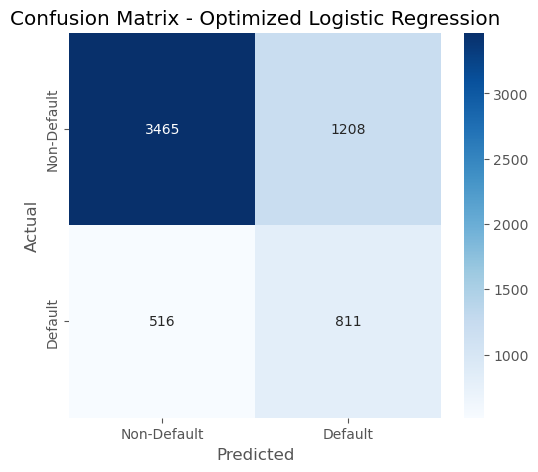

Optimized Random Forest
Accuracy           : 0.7852
Balanced Accuracy  : 0.7129
Precision          : 0.5126
Recall             : 0.5833
F1 Score           : 0.5456
ROC-AUC            : 0.7714
PR-AUC             : 0.5510

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.51      0.58      0.55      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.80      0.79      0.79      6000



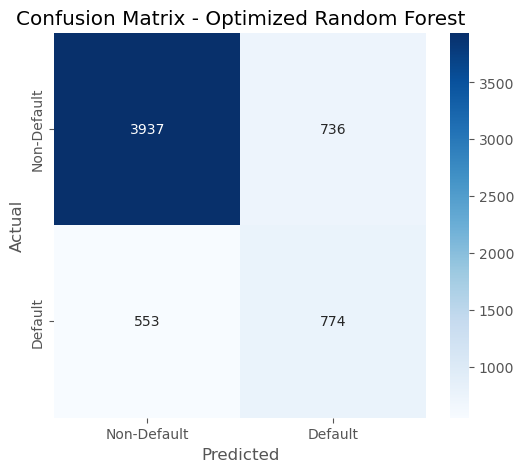

Optimized XGBoost
Accuracy           : 0.7635
Balanced Accuracy  : 0.7100
Precision          : 0.4733
Recall             : 0.6142
F1 Score           : 0.5346
ROC-AUC            : 0.7737
PR-AUC             : 0.5528

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.47      0.61      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



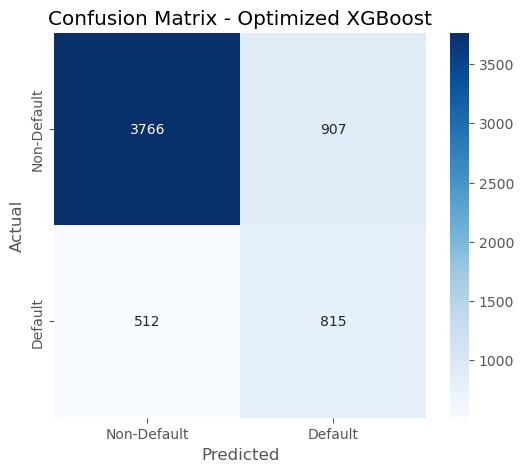

In [121]:
baseline_results = pd.DataFrame(results).copy()

optimized_results_list = []
optimized_model_probs = {}
optimized_trained_models = {}

# temporarily redirect evaluate_model outputs
results = optimized_results_list
model_probs = optimized_model_probs
trained_models = optimized_trained_models

for name, model in optimized_models.items():
    evaluate_model(model, name)

optimized_results = pd.DataFrame(results).copy()

In [122]:
print(baseline_results.columns.tolist())

['Model', 'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'PR-AUC']


In [123]:
comparison = (
    baseline_results[
        [
            "Model",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "PR-AUC"
        ]
    ]
    .merge(
        optimized_results[
            [
                "Model",
                "Accuracy",
                "Balanced Accuracy",
                "Precision",
                "Recall",
                "F1 Score",
                "ROC-AUC",
                "PR-AUC"
            ]
        ],
        left_on="Model",
        right_on=optimized_results["Model"].str.replace("Optimized ", ""),
        suffixes=("_Baseline", "_Optimized")
    )
)

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

for metric in metrics:
    comparison[f"Δ {metric}"] = (
        comparison[f"{metric}_Optimized"] -
        comparison[f"{metric}_Baseline"]
    )

comparison = comparison.round(4)

comparison

,Model,Model_Baseline,Accuracy_Baseline,Balanced Accuracy_Baseline,Precision_Baseline,Recall_Baseline,F1 Score_Baseline,ROC-AUC_Baseline,PR-AUC_Baseline,Model_Optimized,Accuracy_Optimized,Balanced Accuracy_Optimized,Precision_Optimized,Recall_Optimized,F1 Score_Optimized,ROC-AUC_Optimized,PR-AUC_Optimized,Δ Accuracy,Δ Balanced Accuracy,Δ Precision,Δ Recall,Δ F1 Score,Δ ROC-AUC,Δ PR-AUC
0,Logistic Regression,Logistic Regression,0.7132,0.6769,0.4024,0.6119,0.4855,0.7226,0.4919,Optimized Logistic Regression,0.7127,0.6763,0.4017,0.6112,0.4848,0.7220,0.4931,-0.0005,-0.0006,-0.0007,-0.0008,-0.0007,-0.0006,0.0012
1,Random Forest,Random Forest,0.8107,0.6402,0.6370,0.3346,0.4387,0.7524,0.5101,Optimized Random Forest,0.7852,0.7129,0.5126,0.5833,0.5456,0.7714,0.5510,-0.0255,0.0727,-0.1244,0.2487,0.1069,0.0190,0.0410
2,XGBoost,XGBoost,0.7512,0.6843,0.4501,0.5644,0.5008,0.7459,0.5133,Optimized XGBoost,0.7635,0.7100,0.4733,0.6142,0.5346,0.7737,0.5528,0.0123,0.0257,0.0232,0.0497,0.0338,0.0279,0.0395


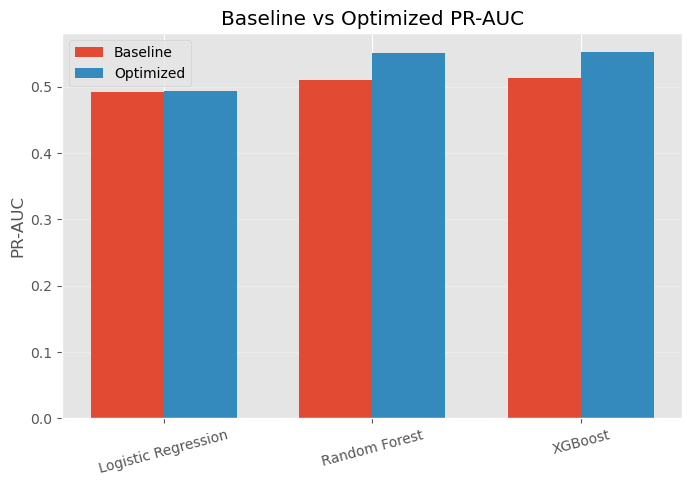

In [124]:
import matplotlib.pyplot as plt
import numpy as np

models = comparison["Model"]

baseline = comparison["PR-AUC_Baseline"]
optimized = comparison["PR-AUC_Optimized"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, baseline, width, label="Baseline")
plt.bar(x + width/2, optimized, width, label="Optimized")

plt.xticks(x, models, rotation=15)
plt.ylabel("PR-AUC")
plt.title("Baseline vs Optimized PR-AUC")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

Hyperparameter optimization was performed using Optuna with 15 trials and 5-fold stratified cross-validation. 

The tuned XGBoost model achieved the highest PR-AUC of 0.5528 on the held-out test set, followed closely by Random Forest (0.5510).

### Model Interpretation

In [125]:
optimized_models.keys()

dict_keys(['Optimized Logistic Regression', 'Optimized Random Forest', 'Optimized XGBoost'])

> Optimized Logistic Regreression

In [126]:
import pandas as pd
import numpy as np

lr_model = optimized_models["Optimized Logistic Regression"]

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
12,average_payment,-0.797744,0.797744,0.450344
5,pay_0,0.587265,0.587265,1.799061
16,payment_volatility,0.461117,0.461117,1.585844
15,bill_volatility,-0.149345,0.149345,0.861272
6,pay_2,0.122474,0.122474,1.130290
14,payment_to_bill_ratio,0.119186,0.119186,1.126579
0,limit_bal,-0.114343,0.114343,0.891952
11,average_bill,0.104079,0.104079,1.109688
7,pay_3,0.095608,0.095608,1.100328
4,age,0.073913,0.073913,1.076714


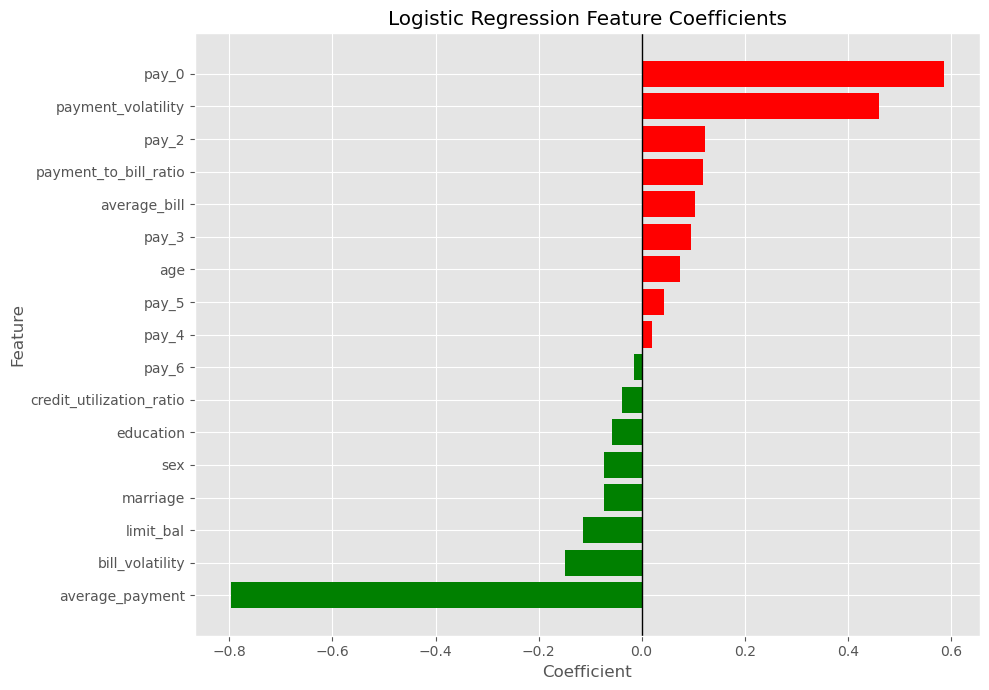

In [127]:
import matplotlib.pyplot as plt

coef_plot = coef_df.sort_values("Coefficient")

plt.figure(figsize=(10, 7))

colors = ["red" if x > 0 else "green" for x in coef_plot["Coefficient"]]

plt.barh(
    coef_plot["Feature"],
    coef_plot["Coefficient"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")

plt.tight_layout()
plt.show()

* ***Interpretation of Logistic Regression Coefficients***

The figure presents the standardized coefficients of the optimized Logistic Regression model. Since all predictor variables were standardized before model training, the coefficients represent the effect of a one standard deviation increase in each predictor on the log-odds of default while holding all other variables constant.

> Features with **positive coefficients** increase the probability of default, whereas features with **negative coefficients** decrease the probability of default. The magnitude of each coefficient reflects the relative importance of the predictor within the linear model.

Among all variables, 

**Average Payment** exhibits the largest negative coefficient, indicating that customers making consistently higher payments are substantially less likely to default. 

Conversely, **PAY_0 (most recent repayment status)** has the largest positive coefficient, suggesting that recent payment delinquency is one of the strongest indicators of future default.

The engineered feature **Payment Volatility** also demonstrates a relatively large positive coefficient, indicating that customers with irregular repayment behavior are at greater risk of default. This highlights the value of feature engineering, as behavioral payment patterns contribute additional predictive information beyond the original repayment status variables.

Several demographic variables, including **Education**, **Sex**, and **Marriage**, have comparatively small coefficients, suggesting that they contribute relatively little to the prediction of default after accounting for financial and repayment-related variables.

Overall, the coefficient plot indicates that repayment behavior and payment consistency are the dominant drivers of credit default risk in the optimized Logistic Regression model.

> Optimized Random Forest

In [128]:
rf_model = optimized_models["Optimized Random Forest"]

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
5,pay_0,0.311308
6,pay_2,0.142822
7,pay_3,0.087380
12,average_payment,0.061670
8,pay_4,0.055908
13,credit_utilization_ratio,0.047148
15,bill_volatility,0.045802
0,limit_bal,0.044161
11,average_bill,0.040558
9,pay_5,0.039623


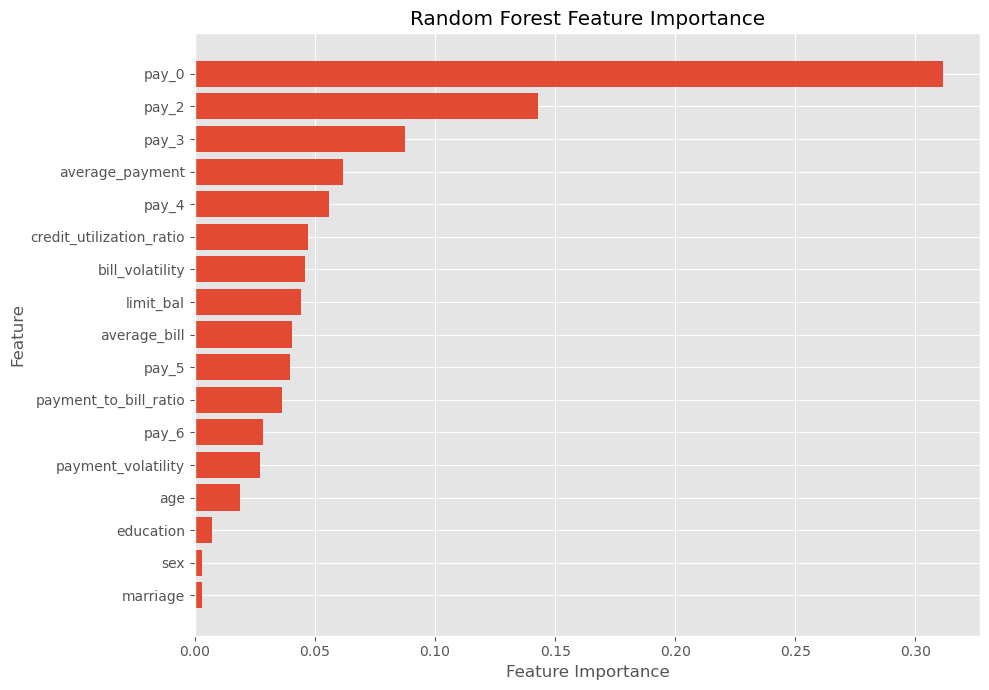

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.barh(
    rf_importance["Feature"][::-1],
    rf_importance["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

* ***Interpretation of Random Forest Feature Importance***

- The feature importance plot illustrates the relative contribution of each predictor to the Random Forest model's classification performance. Higher importance values indicate that a feature contributes more to reducing impurity across the ensemble of decision trees.

- **Recent repayment status variables (PAY_0, PAY_2, and PAY_3)**, which capture the customer's payment delinquency over the most recent months, are the most influential predictors of default.

- Among the engineered variables, **Average Payment**, **Credit Utilization Ratio**, **Bill Volatility**, **Average Bill**, and **Payment-to-Bill Ratio** rank among the top predictors. This demonstrates that the engineered financial and behavioral features provide additional predictive information beyond the original dataset.

- Demographic characteristics such as **Education**, **Sex**, and **Marriage** exhibit very low feature importance, suggesting that these variables contribute minimally to the prediction of default compared with repayment history and financial behavior.

- ***Compared with the Logistic Regression model***,


  **the Random Forest assigns greater importance to multiple repayment status variables (PAY_0–PAY_5), reflecting its ability to capture nonlinear relationships and interactions among predictors.** Overall, the results indicate that repayment history remains the primary driver of credit default, while engineered behavioral features further enhance predictive performance.

> Optimized XGBoost

In [130]:
xgb_model = optimized_models["Optimized XGBoost"]

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
5,pay_0,0.419960
6,pay_2,0.116325
7,pay_3,0.071013
8,pay_4,0.050168
12,average_payment,0.040470
9,pay_5,0.039236
0,limit_bal,0.031361
10,pay_6,0.029193
11,average_bill,0.029160
13,credit_utilization_ratio,0.028686


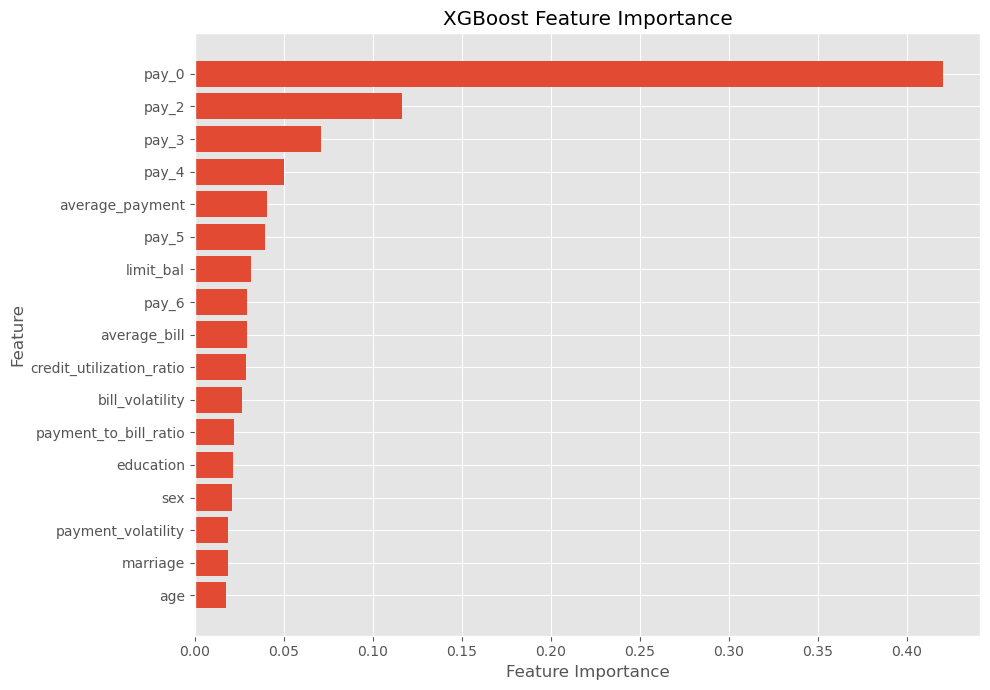

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.barh(
    xgb_importance["Feature"][::-1],
    xgb_importance["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

* ***Interpretation of XGBoost Feature Importance***

- The feature importance plot illustrates the relative contribution of each predictor to the optimized XGBoost model. Features with higher importance values have a greater influence on the model's ability to distinguish between defaulting and non-defaulting customers.

- **Recent repayment history** is the strongest predictor of default. In particular, **PAY_0 (repayment status in the most recent month)** contributes the highest importance, followed by **PAY_2**, **PAY_3**, and **PAY_4**.

- The engineered features, including **Average Payment**, **Average Bill**, **Credit Utilization Ratio**, **Bill Volatility**, and **Payment-to-Bill Ratio**, also contribute meaningfully to the model.

- Demographic characteristics such as **Age**, **Marriage**, **Sex**, and **Education** exhibit relatively low feature importance, suggesting that customer financial behaviour is substantially more informative than demographic attributes when predicting default.

- ***Compared with the Logistic Regression and Random Forest models,***

  **the optimized XGBoost model places the greatest emphasis on recent repayment behaviour while effectively incorporating engineered financial features.**





  Since XGBoost achieved the highest predictive performance among all evaluated models, it was selected for further interpretation using SHAP (SHapley Additive exPlanations). 

## ***SHAP***

In [132]:
import shap

shap.initjs()

In [133]:
xgb_model = optimized_models["Optimized XGBoost"]

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test) 

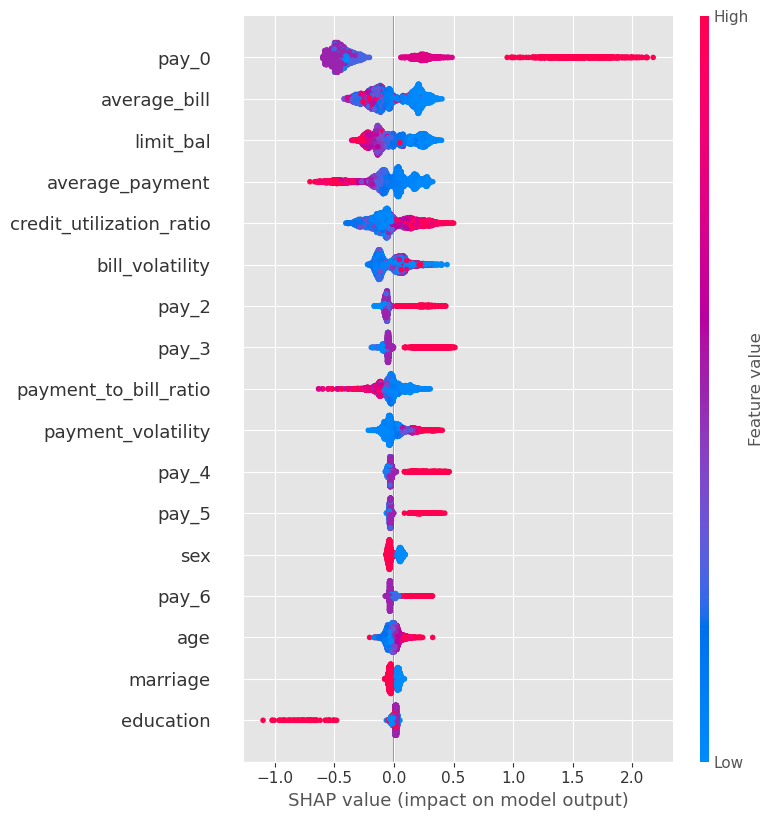

In [134]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.show()

### Interpretation of SHAP Beeswarm Plot

- The SHAP summary plot provides a **global explanation** of the optimized XGBoost model by illustrating both the importance of each feature and the direction of its influence on the predicted probability of default. Features are ranked according to their average absolute SHAP values, while each point represents an individual observation.

- The most influential predictor is **PAY_0 (repayment status in the most recent month)**, followed by **Average Bill**, **Credit Limit**, **Average Payment**, and **Credit Utilization Ratio**. This confirms that recent repayment behaviour is the primary driver of credit default prediction, consistent with the findings from the XGBoost feature importance analysis.

- The colour gradient indicates the magnitude of each feature value, where **red represents higher values** and **blue represents lower values**. Features with positive SHAP values increase the predicted probability of default, whereas negative SHAP values reduce the predicted probability.

- The summary plot also reveals the direction of each feature's impact. For example, **higher repayment delay values (PAY_0, PAY_2, and PAY_3)** generally increase the predicted risk of default, while **higher average payments** tend to reduce the probability of default. Similarly, customers with larger credit limits generally exhibit lower predicted default risk.

- Compared with conventional feature importance measures, SHAP provides a more comprehensive interpretation by simultaneously identifying the relative importance of each predictor, the direction of its influence, and the variation of its impact across individual customers.

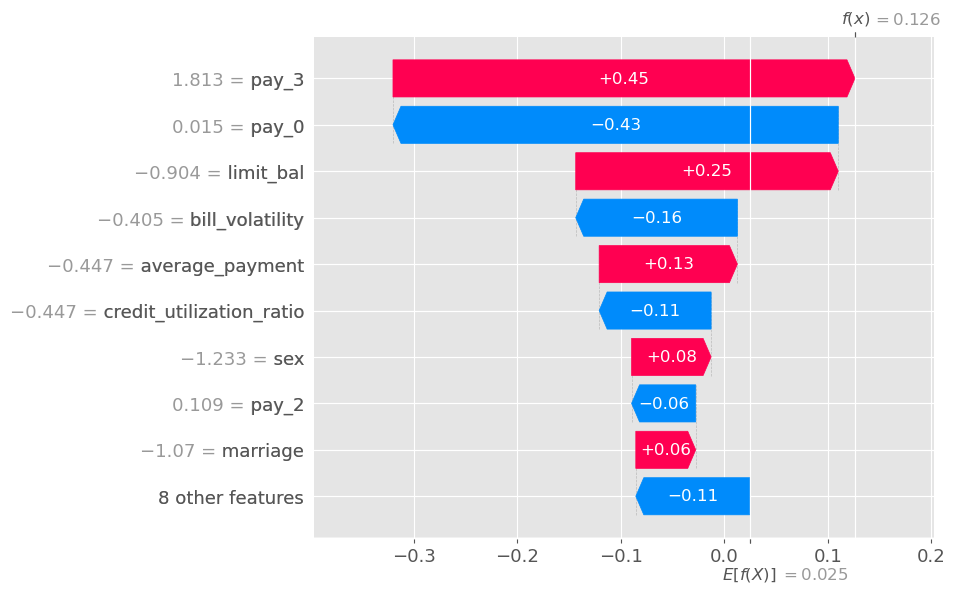

In [135]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

### Interpretation of SHAP Waterfall Plot

- The SHAP waterfall plot explains the prediction for an individual customer by decomposing the model's output into the contribution of each feature. The prediction begins from the **baseline prediction**, representing the average predicted probability of default across all observations, and each feature subsequently increases or decreases the final prediction.

- In this example, the model predicts a **default probability of approximately 12.6%**, compared with the baseline prediction of **2.5%**. The difference between these values is explained by the cumulative contribution of the customer's characteristics.

- The customer's **PAY_3 (repayment status)** contributes the largest increase in predicted default risk, followed by **Credit Limit**, **Average Payment**, **Sex**, and **Marriage**, all of which push the prediction towards a higher probability of default. Conversely, **PAY_0**, **Bill Volatility**, **Credit Utilization Ratio**, and **PAY_2** reduce the predicted default probability for this customer.

- The magnitude of each bar represents the contribution of the corresponding feature to the prediction. Positive SHAP values increase the predicted probability of default, while negative SHAP values decrease it. Larger bars indicate a greater influence on the model's decision.

- The waterfall plot demonstrates the local interpretability of the optimized XGBoost model by providing a transparent explanation of how individual customer characteristics combine to produce a specific prediction. This level of interpretability is particularly valuable in credit risk modelling, where understanding the rationale behind individual lending decisions is essential for regulatory compliance and model transparency.

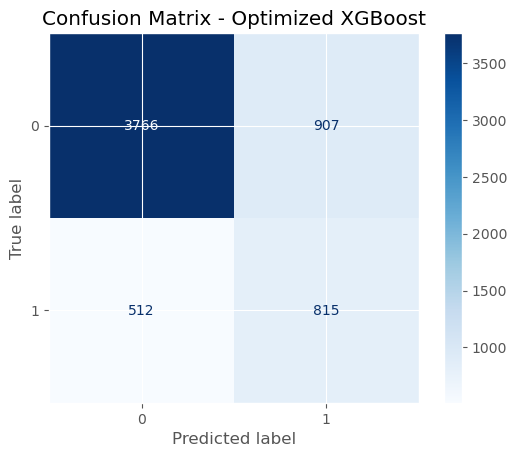

In [138]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    optimized_models["Optimized XGBoost"],
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Optimized XGBoost")
plt.show()

## Overall Discussion

The objective of this study was to develop and evaluate machine learning models for predicting credit card default using demographic characteristics, repayment history, and engineered financial behaviour features. Three optimized classification models, namely Logistic Regression, Random Forest, and Extreme Gradient Boosting (XGBoost), were developed and compared using multiple evaluation metrics, including Accuracy, Balanced Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

Among the evaluated models, the optimized XGBoost model demonstrated the strongest overall predictive performance. Although the Random Forest model achieved a slightly higher F1-score (0.546 compared to 0.535), XGBoost obtained the highest ROC-AUC (0.774) and PR-AUC (0.553), indicating superior discrimination between defaulting and non-defaulting customers. Since PR-AUC is particularly informative for imbalanced classification problems such as credit default prediction, XGBoost was selected as the final model for interpretation.

The feature interpretation analyses consistently revealed that **recent repayment behaviour** was the most influential determinant of credit default. Across Logistic Regression, Random Forest, XGBoost feature importance, and SHAP analysis, the repayment status variables (PAY_0, PAY_2, and PAY_3) repeatedly emerged as the strongest predictors. This finding suggests that customers who exhibit recent payment delays are substantially more likely to default than customers with a history of timely repayments.

In addition to the original repayment variables, the engineered behavioural features contributed meaningfully to model performance and interpretation. Variables such as Average Payment, Average Bill, Credit Utilization Ratio, Payment-to-Bill Ratio, Bill Volatility, and Payment Volatility consistently ranked among the most important predictors across the machine learning models. These engineered variables capture customers' repayment behaviour and spending patterns more effectively than individual monthly observations, thereby providing additional predictive information.

The SHAP analysis further enhanced the interpretability of the optimized XGBoost model by explaining both global feature importance and individual customer predictions. The SHAP summary plot confirmed the dominant influence of repayment history while illustrating how different feature values increase or decrease the probability of default. Furthermore, the SHAP waterfall plot demonstrated how individual customer characteristics collectively contribute to a specific prediction, thereby improving the transparency of the model's decision-making process.

Overall, the findings indicate that machine learning models, particularly XGBoost, provide an effective framework for probability of default modelling. The combination of repayment history variables and engineered financial behaviour features enables accurate identification of high-risk borrowers while maintaining model interpretability through SHAP-based explanations. Such models can support financial institutions in strengthening credit risk assessment, identifying potential defaults at an early stage, and improving data-driven lending decisions.